# Exploratory Data Analysis
<!-- 
## Time spent
|  Name  | Time   |
| ---    |  ---   |
| Danylo | 40 min |
| Ivan   | 5 min  |
| Daryna | 0 min  |
-->
## Plan (temporary)
Danylo - reddit and H1
Ivan & Daryna - kaggle

## Overview
Since our goal has some specifics, we will follow our own flow with exploration and analysis of data. To be exact, we already have our hypotheses and we will try to find approaches in order to prove those hypothese right, or wrong. We will not follow guidelines or try to check any boxes, instead we will follow our curiosity and play until we have the answer.

However, there is one guideline: before freestyling with analysis, explore the data and brainstorm what visualizations should be made.

### Hypotheses
- H1: Discourse is getting shorter and simpler
    - Lexical & NLP approach
    - Temporal/Behavioral aspect
- H2: Short-form platforms accelerated the degradation of discourse
- H3: Wellbeing is getting worse among doomscrollers
- H4: Crises intensify doomscrolling and negativity

### Additional approches
- questionnaire
- YouTube comments

## H1: Discourse is getting shorter and simpler
>Only Danylo works below
Time spent: 60min

In [2]:
# placeholder

## H3 probably
> Only Darka works below
Time spent: 5 min

## H4 probably
> Only Ivan works below
Time spent: 390 min

First, i need to define what actuall datasets i can use for checking this hypothesis(YT trending videos, reddit comments, GDELT events, idk still). Then figure out how to process them, and compare so that this hypothesis is verifyable.

I'll start by what datasets i can and want to use.

---
### H4 analysis: code and data
Code: the chart code is in the cells below; `src/events.py` (event study, placebo test, change-points, session and author statistics) and `src/textmining.py` (per-comment tone and crisis-word features) prepare the data. Every chart is listed in `docs/figure_index.md`, every script is explained in `docs/code_guide.md`, and the numbers quoted below are reproduced by `src/checks.py`.

**Data used here.** Six subreddits (r/memes, r/teenagers, r/books, r/explainlikeimfive, r/todayilearned, r/nosurf), January 2012 to September 2026, from Arctic Shift. The raw files are a random time-slot sample (about 10k comments per subreddit-month), except r/nosurf, which is complete. Cleaned comments only: bots, moderator messages, templated text, removed text and spam are dropped (`src/io_reddit.py`).

In [2]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "src").exists():  # opened from subfolder
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")

## Design of the H4 analysis
**Question.** Do crises intensify negativity and doomscrolling-like behaviour? Reddit records posting, not reading, so "doomscrolling" can only be proxied (talk about it, and patterns of active posting). Claims stay at community level: no statement about individuals or clinical mood.

**Events inside the data range** (dates checked on 2026-10-04 against news and reference sources): the WHO declares COVID-19 a pandemic (11 March 2020), the full-scale Russian invasion of Ukraine (24 February 2022), the Hamas attack on Israel that starts the Gaza war (7 October 2023), and the assassination of Charlie Kirk (10 September 2025). The last one was not on our first list: it showed up as the busiest r/nosurf day (11 September 2025: 530 comments, 2.8 times the month before; three threads carried 72% of the day, the two biggest about the killing).

**Communities.** Short-form (r/memes + r/teenagers), long-form (r/books + r/explainlikeimfive), baseline (r/todayilearned) and r/nosurf. **No news subreddits are in the data yet** (r/worldnews and r/news were planned), so this is only the half of the design that asks whether non-news communities react; we cannot yet show that news communities react more.

**Statistic and placebo test.** For each event and community, the change in an outcome between the 8 weeks before the event (days -56 to -1) and the 4 weeks after (days 0 to 27), computed as a ratio of sums over all comments in the window. To judge whether a change is large we repeat exactly the same calculation at 400 random fake dates (never within 120 days of a real event); `p` is the share of fake dates with an equal or larger change in absolute size. We use this instead of a textbook standard error because the data are time-slot samples (about 10-15 slots a month in the big subreddits), so day-to-day values are sparse and autocorrelated.

**Outcomes.** Mean VADER compound score (tone), words about the event itself (to check the event reached the community), crisis words in general, `doomscroll*` mentions, brainrot words (rizz, skibidi, gyatt, brain rot, tung tung, mewing) and the length of posting sessions. VADER is a word list; it has not yet been compared with hand-labeled comments (a 100-comment file is ready for the team in `data/processed/derived/`).

**Checked but not charted.** The daily rhythm of r/nosurf (hour by weekday), a monthly world uncertainty index, change-points in each community's monthly tone and brainrot words week by week around the events (see the summary at the end). **Not done.** Emotion categories (fear, anger, sadness): the NRC lexicon is not available offline; US anxiety/depression indicators from the CDC; news subreddits (see above).

## Chart code
Every chart below is drawn by the code in its own cell. The first two cells hold what all H4 charts share: the imports, then the style (Jost font, colours, caps topic title, legend box, event chips, save). Helpers a chart needs appear in the first cell that uses them. Data preparation (cleaning, features, the event study and its placebo test, the session and author statistics) is in `src/` (`io_reddit.py`, `textmining.py`, `events.py`) and is explained in `docs/code_guide.md`.

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize
from scipy.interpolate import PchipInterpolator
from matplotlib.patches import Polygon, Rectangle
from src import events as ev
from src.config import AGG, EVENTS, ORDER, SHORT_EVENTS as EV_SHORT
from IPython.display import Markdown, display

In [4]:
import textwrap
from contextlib import contextmanager
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from src.config import ROOT

# H4 look: jost, no frame, soft gray axes
# hack: ttfs share one family name, so one FontEntry per weight
H4_INK, H4_MUTED, H4_FAINT, H4_GRID = "#1c1c1c", "#6f6f6f", "#9b9b9b", "#e6e6e6"
H4_SUB = {"teenagers": "#E8575F", "memes": "#A82E3C", "books": "#C46FBC", "explainlikeimfive": "#8A2B87",
          "todayilearned": "#E9A23B", "nosurf": "#10A38E"}  # danylo's hues
H4_GROUP = {"short_form": "#C9404B", "long_form": "#8A2B87", "baseline": "#E9A23B", "reflective": "#10A38E"}
H4_GROUP_LABEL = {"short_form": "r/memes + r/teenagers", "long_form": "r/books + r/explainlikeimfive",
                  "baseline": "r/todayilearned", "reflective": "r/nosurf"}
H4_RAMP_COLORS = ["#003f5c", "#594e90", "#bc4c96", "#ff5f66", "#ffa600"]
H4_RAMP = LinearSegmentedColormap.from_list("h4_ramp", H4_RAMP_COLORS)
H4_TERMS = {"rizz": "#ffa600", "skibidi": "#bc4c96", "gyatt": "#594e90", "brain rot": "#003f5c", "tung tung": "#ff5f66", "mewing": "#7a9cb0"}
_FONTS_DONE = []


def label_color(color):
    return {"#E9A23B": "#B87A14", "#ffa600": "#B87300", "#10A38E": "#0A7566", "#7a9cb0": "#4E7388"}.get(color, color)


def register_jost():
    if _FONTS_DONE:
        return
    for w, f in {300: "Light", 400: "Medium", 500: "Medium", 600: "SemiBold", 700: "Bold", 800: "ExtraBold"}.items():  # 400 = regular
        path = ROOT / "fonts" / f"Jost-{f}.ttf"
        if path.exists():
            fm.fontManager.ttflist.append(fm.FontEntry(fname=str(path), name="Jost", style="normal", variant="normal",
                                                       weight=w, stretch="normal", size="scalable"))
    _FONTS_DONE.append(True)


@contextmanager
def h4_style():
    register_jost()
    rc = {"font.family": "Jost", "font.size": 11, "text.color": H4_INK, "axes.labelcolor": H4_FAINT, "axes.labelsize": 10,
          "axes.labelweight": 600, "xtick.color": H4_FAINT, "ytick.color": H4_FAINT, "xtick.labelsize": 10, "ytick.labelsize": 10,
          "xtick.major.size": 0, "ytick.major.size": 0, "axes.spines.top": False, "axes.spines.right": False,
          "axes.spines.left": False, "axes.spines.bottom": False, "axes.grid": True, "grid.color": H4_GRID, "grid.linewidth": 0.8,
          "axes.axisbelow": True, "axes.titlelocation": "left", "figure.facecolor": "white", "axes.facecolor": "white"}
    with plt.rc_context(rc):
        yield


def h4_title(fig, text, size=26):
    H = fig.get_figheight()
    fig.text(0.012, 1 - 0.14 / H, text.upper(), fontsize=size, fontweight=800, va="top", ha="left", color=H4_INK)
    return 1 - (0.14 + size / 72 * 1.25 + 0.22) / H  # returns plot-area top, fig fraction


def h4_foot(fig, text, width=185):
    fig.text(0.012, 0.012, textwrap.fill(text, width), fontsize=8.5, fontweight=300, color=H4_FAINT, va="bottom", ha="left")


def h4_legend(fig, entries, x_right=0.985, y_top=None, ncol=None, col_w=1.55):
    # entries: (label, color, style)
    from matplotlib.patches import Rectangle
    W, H = fig.get_size_inches()
    ncol = ncol or min(len(entries), 4)
    rows = -(-len(entries) // ncol)
    row_h, pad = 0.42, 0.18
    box_w, box_h = ncol * col_w + 2 * pad - 0.16, rows * row_h + 0.2
    y_top = (1 - 0.12 / H) if y_top is None else y_top
    lg = fig.add_axes([x_right - box_w / W, y_top - box_h / H, box_w / W, box_h / H])
    lg.set_xlim(0, box_w)
    lg.set_ylim(0, box_h)
    lg.axis("off")
    lg.add_patch(Rectangle((0.04, -0.04), box_w, box_h, facecolor="#eeeeee", edgecolor="none", clip_on=False, zorder=0))
    lg.add_patch(Rectangle((0, 0), box_w, box_h, facecolor="white", edgecolor="#d6d6d6", linewidth=1, clip_on=False, zorder=1))
    for i, (lab, col, style) in enumerate(entries):
        x0, y0 = pad + (i % ncol) * col_w, box_h - 0.15 - (i // ncol) * row_h
        lg.text(x0, y0, lab, fontsize=9.5, fontweight=700, color=H4_INK, va="top", ha="left", zorder=2)
        if style == "outline":
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.2, zorder=2))
        elif style:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.3, hatch=style, edgecolor=col, linewidth=0, zorder=2))
        else:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, edgecolor="none", zorder=2))
    return lg


def h4_chips(ax, events, ypos=1.0, fontsize=9):
    import pandas as pd
    for date, label in events:
        ax.axvline(pd.Timestamp(date), color="#333", lw=0.9, ls=(0, (4, 3)), alpha=0.75, zorder=1)
        ax.annotate(label, (pd.Timestamp(date), ypos), xycoords=("data", "axes fraction"), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, fontweight=600, color="#333",
                    bbox=dict(boxstyle="round,pad=0.25", fc="#f2f2f2", ec="none"), annotation_clip=False)


def h4_done(fig, finding, how):
    fig.h4_finding, fig.h4_how = finding, how
    return fig

### Q1. Do crises show up in what people write?
**Why we asked:** An effect on tone only makes sense if the crisis was part of the conversation.

**What we did:** Monthly rate of a broad list of crisis words (war, pandemic, covid, lockdown, invasion, Ukraine, Gaza, Hamas, Israel, Palestine, genocide, terror, shooting, assassination, crisis, recession, famine, refugees, earthquake, hurricane) per 10,000 words as one line per subreddit on one scale (highlighted line chart: r/memes in colour, the other five in gray), 3-month mean; months with under 50,000 words (too little text) count as 0, so a line slopes down to the axis where a subreddit has no usable sample and stops there; the four events are dashed lines.

**Result:** r/memes shows one clear crisis peak: 34 crisis words per 10,000 words in March 2022, 4.1 times its monthly median (8.2). The other communities have no common peak: r/teenagers peaks in July 2026 (18.2, median 4.2), r/books in December 2025 (12.3, median 5.9), r/todayilearned in August 2022 (18.4, median 11.6), r/nosurf in December 2020 (6.8, median 3.1) and r/explainlikeimfive in October 2012 (14.8, median 5.4).

**Interpretation:** Only r/memes reacts strongly in the broad measure. Words like war, crisis or shooting appear in games, history, books and jokes all the time, so the broad list is noisy. The event-specific words in Q2 are the cleaner check.

**Next question:** Did each event actually reach each community (Q2)?

**Crisis talk spikes once in r/memes (Mar 2022: 34 per 10,000 words, 4.1x its median); the other communities peak at different times.**

*How to read: One line per subreddit: crisis words per 10,000 words, 3-month average; months with too little text count as 0, so a line slopes down to the axis where it starts or stops. r/memes in colour, the other communities in gray. Dashed lines = the four events.*

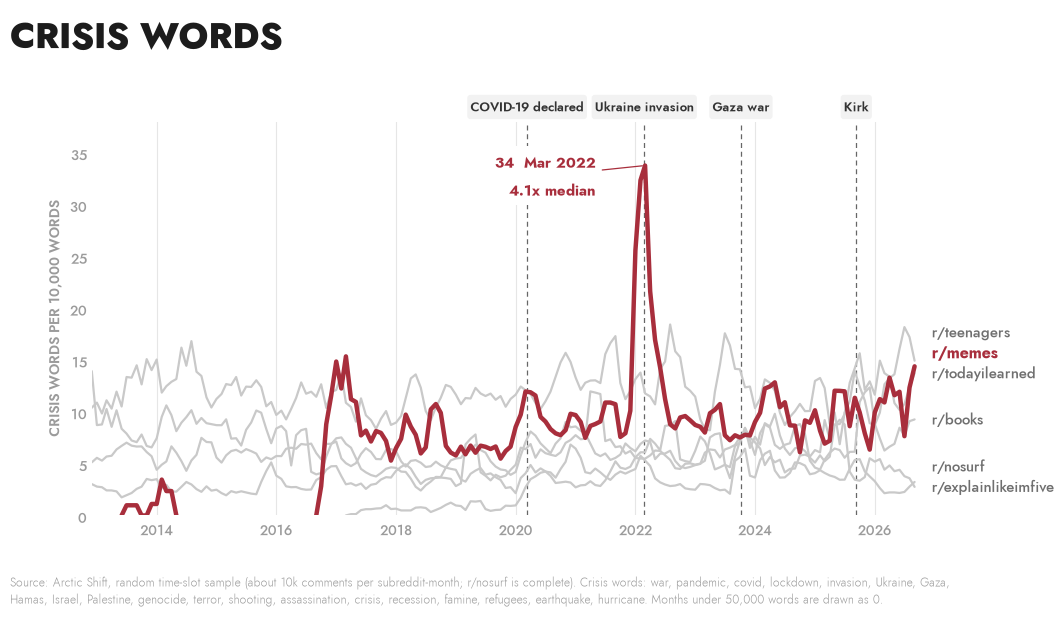

In [5]:
CRISIS_NOTE = ("Crisis words: war, pandemic, covid, lockdown, invasion, Ukraine, Gaza, Hamas, Israel, Palestine, genocide, terror, shooting, "
               "assassination, crisis, recession, famine, refugees, earthquake, hurricane.")


SAMPLE = "Source: Arctic Shift, random time-slot sample (about 10k comments per subreddit-month; r/nosurf is complete)."


CHIPS = [(v, EV_SHORT[k]) for k, v in EVENTS.items()]


def _axbox(fig, left, bottom, right, top):
    # margins in inches
    W, H = fig.get_size_inches()
    return [left / W, bottom / H, (W - left - right) / W, (H - bottom - top) / H]


def _top_in(fig, top_frac):
    # inches from top to plot area
    return (1 - top_frac) * fig.get_figheight()


def _year_axis(ax, step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(step, month=1, day=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)


def c20():
    d = ev.load_daily()
    months = pd.date_range(d.day.min().to_period("M").to_timestamp(), d.day.max().to_period("M").to_timestamp(), freq="MS")
    raw, sm = {}, {}
    for s in ORDER:
        x = d[d.subreddit == s].assign(month=lambda z: z.day.dt.to_period("M").dt.to_timestamp())
        g = x.groupby("month")[["hits_crisis", "tokens"]].sum()
        g = g[g.tokens >= 50_000]
        r = g.hits_crisis / g.tokens * 1e4
        raw[s] = r
        f = r.reindex(months).fillna(0).rolling(3, min_periods=1, center=True).mean()  # gap months = 0, ramps to axis
        sm[s] = f.where((f > 0) | (f.shift(1) > 0) | (f.shift(-1) > 0))  # no flat zero line through empty years
    pk, pv = sm["memes"].idxmax(), sm["memes"].max()
    finding = (f"Crisis talk spikes once in r/memes ({pk:%b %Y}: {pv:.0f} per 10,000 words, {pv / raw['memes'].median():.1f}x "
               f"its median); the other communities peak at different times.")
    how = ("One line per subreddit: crisis words per 10,000 words, 3-month average; months with too little text count as 0, so a line slopes down to the axis where it starts or stops. r/memes in colour, "
           "the other communities in gray. Dashed lines = the four events.")
    ymax = 38
    with h4_style():
        fig = plt.figure(figsize=(11, 6.2))
        top = _top_in(fig, h4_title(fig, "Crisis words"))
        ax = fig.add_axes(_axbox(fig, 0.95, 1.0, 1.75, top + 0.45))
        for s in ORDER:
            if s != "memes":
                ax.plot(sm[s].index, sm[s], color="#c9c9c9", lw=1.6, zorder=3, solid_capstyle="round")
        ax.plot(sm["memes"].index, sm["memes"], color=H4_SUB["memes"], lw=3.2, zorder=6, solid_capstyle="round")
        placed = []  # dodge end labels
        for v, s in sorted((sm[s].iloc[-1], s) for s in ORDER):
            placed.append((max(v, placed[-1][0] + 0.052 * ymax) if placed else v, s))
        for y, s in placed:
            hi = s == "memes"
            ax.text(1.012, y, f"r/{s}", transform=ax.get_yaxis_transform(), fontsize=11.5 if hi else 10.5, fontweight=700 if hi else 500,
                    color=label_color(H4_SUB[s]) if hi else H4_MUTED, va="center", ha="left")
        ax.annotate(f"{pv:.0f}  {pk:%b %Y}\n{pv / raw['memes'].median():.1f}x median", xy=(pk, pv), xytext=(pk - pd.Timedelta(days=300), pv - 1),
                    ha="right", va="center", fontsize=10.5, fontweight=700, color=H4_SUB["memes"], linespacing=1.3,
                    bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"), zorder=8,
                    arrowprops=dict(arrowstyle="-", color=H4_SUB["memes"], lw=0.9, shrinkA=3, shrinkB=2))
        h4_chips(ax, CHIPS, ypos=1.0)
        _year_axis(ax, 2)
        ax.set_xlim(pd.Timestamp("2012-12-01"), pd.Timestamp("2026-10-15"))
        ax.set_ylim(0, ymax)
        ax.set_yticks(range(0, 36, 5))
        ax.set_ylabel("CRISIS WORDS PER 10,000 WORDS")
        h4_foot(fig, f"{SAMPLE} {CRISIS_NOTE} Months under 50,000 words are drawn as 0.")
        return h4_done(fig, finding, how)


fig = c20()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C20:** drawn by the cell above; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q2. Did each event reach each community?
**Why we asked:** If an event leaves no trace in a community's vocabulary, finding no change in tone there says little.

**What we did:** Extra event-specific words (covid/pandemic/lockdown; Ukraine/Russia/Putin/invasion; Gaza/Hamas/Israel/Palestine; Kirk/Turning Point/assassination) per 10,000 words in the 4 weeks after each event, compared with the 8 weeks before, as bars: one panel per event, one bar per community group, each panel on its own scale; solid = beyond random dates (p < 0.05), faded and hatched = not.

**Result:** Event words rose in 13 of 16 community-event pairs (p < 0.05 against random dates). Short-form: +8.2 (COVID), +56.4 (Ukraine), +5.6 (Gaza), +4.1 (Kirk) per 10,000 words. Long-form: +4.6, +2.1, +3.9, +2.0. r/nosurf: +6.3, +5.0, +5.0, +5.2. r/todayilearned reacted to COVID (+4.0) but not to the other three (+0.4, -0.6, +0.3).

**Interpretation:** All three conversational communities noticed all four events; the Ukraine invasion dominated r/memes and r/teenagers. r/todayilearned, a feed of facts, is the exception, so it is a useful low-exposure comparison. This is the manipulation check for the tests that follow.

**Next question:** Did tone change with the attention (Q3)?

**Every event reached the communities: event words rose in 13 of 16 community-event pairs (p < 0.05 against random dates); r/todayilearned barely reacted to 3 of the four events.**

*How to read: One panel per event, one bar per community: extra event words per 10,000 words in the 4 weeks after the event, compared with the 8 weeks before. Each panel has its own scale. Solid bar = beyond what random dates produce (p < 0.05); faded and hatched = not.*

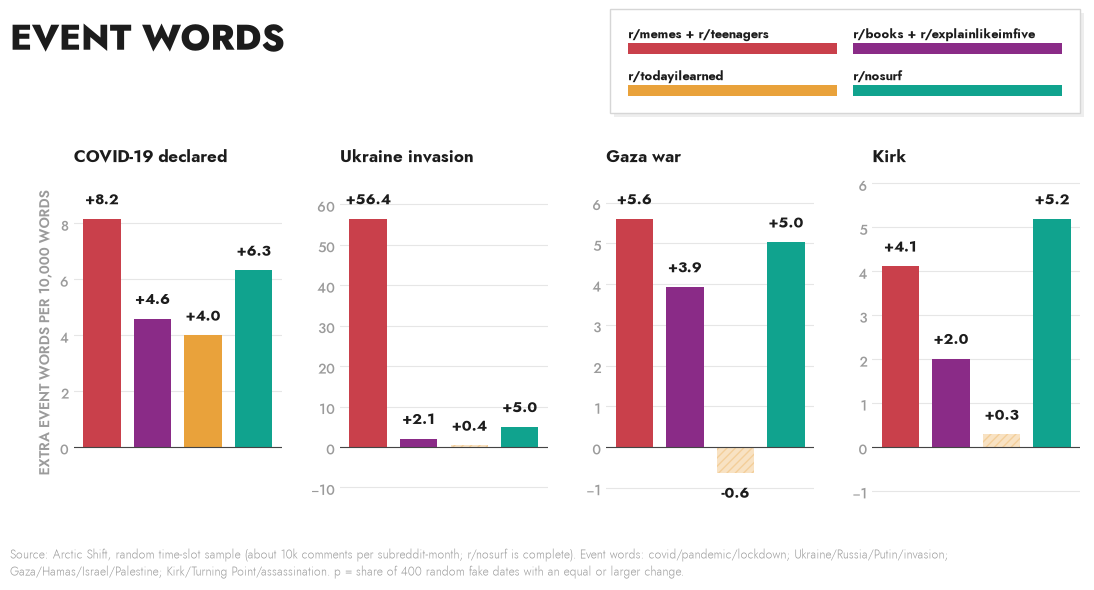

In [6]:
EV_NAMES = list(EVENTS)


def _eff(group, event, outcome):
    t = ev.effects_table_cached()
    r = t[(t.group == group) & (t.event == event) & (t.outcome == outcome)].iloc[0]
    return float(r.effect), float(r.p)


def c20b():
    gk = list(ev.GROUPS)
    cells = {(n, g): _eff(g, n, ev.EVENT_OUTCOME[n]) for n in EV_NAMES for g in gk}
    n_sig = sum(1 for (e, p) in cells.values() if p < 0.05 and e > 0)
    quiet = sum(1 for n in EV_NAMES if cells[(n, "baseline")][1] >= 0.05)
    finding = (f"Every event reached the communities: event words rose in {n_sig} of {len(cells)} community-event pairs (p < 0.05 against random dates); "
               f"r/todayilearned barely reacted to {quiet} of the four events.")
    how = ("One panel per event, one bar per community: extra event words per 10,000 words in the 4 weeks after the event, compared with the 8 weeks "
           "before. Each panel has its own scale. Solid bar = beyond what random dates produce (p < 0.05); faded and hatched = not.")
    with h4_style():
        fig, axes = plt.subplots(1, 4, figsize=(11, 5.9))
        top = _top_in(fig, h4_title(fig, "Event words"))
        for ax, n in zip(axes, EV_NAMES):
            vals = [cells[(n, g)] for g in gk]
            m = max(abs(v[0]) for v in vals) or 1
            for i, (g, (e, p)) in enumerate(zip(gk, vals)):
                sig = p < 0.05
                ax.bar(i, e, color=H4_GROUP[g], alpha=1 if sig else 0.3, width=0.74, hatch=None if sig else "////", ec=H4_GROUP[g], lw=0)
                ax.text(i, e + 0.04 * m * (1 if e >= 0 else -1), f"{e:+.1f}", ha="center", va="bottom" if e >= 0 else "top", fontsize=10.5,
                        fontweight=700, color=H4_INK)
            ax.set_title(f"{EV_SHORT[n]}", fontsize=12.5, fontweight=700, pad=8)
            ax.axhline(0, color="#444", lw=0.8)
            ax.set_xticks([])
            ax.grid(axis="x", visible=False)
            ax.set_ylim(-0.2 * m, 1.2 * m)
        axes[0].set_ylabel("EXTRA EVENT WORDS PER 10,000 WORDS")
        fig.subplots_adjust(top=1 - (top + 0.95) / fig.get_figheight(), bottom=0.16, left=0.07, right=0.985, wspace=0.28)
        h4_legend(fig, [(H4_GROUP_LABEL[g], H4_GROUP[g], None) for g in gk] , ncol=2, col_w=2.25)
        h4_foot(fig, f"{SAMPLE} Event words: covid/pandemic/lockdown; Ukraine/Russia/Putin/invasion; Gaza/Hamas/Israel/Palestine; Kirk/Turning Point/assassination. "
                     "p = share of 400 random fake dates with an equal or larger change.")
        return h4_done(fig, finding, how)


fig = c20b()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C20b:** drawn by the cell above; reads `daily_features`, `event_effects`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q3. Did tone get more negative after the events? (H4)
**Why we asked:** H4: crises intensify negativity. The core signal is spillover into communities that are not about news.

**What we did:** Change in mean VADER compound score (-1 to +1) in the 4 weeks after each event versus the 8 weeks before, for four community groups and four events, as a tile matrix on one scale in the colours of the tone-change chart Q7 (dark blue = tone fell, amber = tone rose, magenta = no change). A ring marks tiles beyond the placebo range (p < 0.05); each tile shows its p-value.

**Result:** After the three violent events (Ukraine, Gaza, Kirk) tone was lower than before in 11 of the 12 community-event pairs (the twelfth, r/todayilearned after Kirk, is zero), by up to 0.05 compound points. The largest drops are in r/nosurf (Kirk -0.053, Gaza -0.050), r/todayilearned (Ukraine -0.044) and long-form (Ukraine -0.038). After the COVID declaration tone rose slightly in three groups (+0.007 to +0.019) and fell in r/nosurf (-0.037). Three of the 16 tiles are ringed: r/nosurf after Gaza (p = 0.04) and after Kirk (p = 0.03), and r/todayilearned after Ukraine (p = 0.04); about 0.8 would be expected by chance.

**Interpretation:** How the placebo test works: we compute the same before/after change at 400 random fake dates and ask how often a fake date gives a change at least as large; that share is p. If the 16 tests were independent, three or more ringed tiles would happen about 4% of the time by chance. They are not independent (the same weeks and communities recur) and we ran many tests, so we do not call this a finding. What we can say: any effect of these events on tone is small and, for most communities, indistinguishable from weekly noise. For scale, r/nosurf's mean tone fell by 0.20 over nine years (0.36 in 2017, 0.16 in 2026).

**Next question:** Does talk about doomscrolling rise with the crises (Q4)?

**After the three violent events tone dipped in 11 of 12 community-event pairs, by no more than 0.05 compound points; 3 of 16 tests (ringed) fall outside random dates, 0.8 expected by chance alone.**

*How to read: Each tile is one community and one event. The number is the change in mean tone (VADER, -1 to +1) in the 4 weeks after, compared with the 8 weeks before. Dark blue = tone fell, amber = tone rose (the colours of the tone-change chart of the same authors), same scale in every tile. A thick ring means the change is beyond what random dates produce (p < 0.05); the p-value is in each tile.*

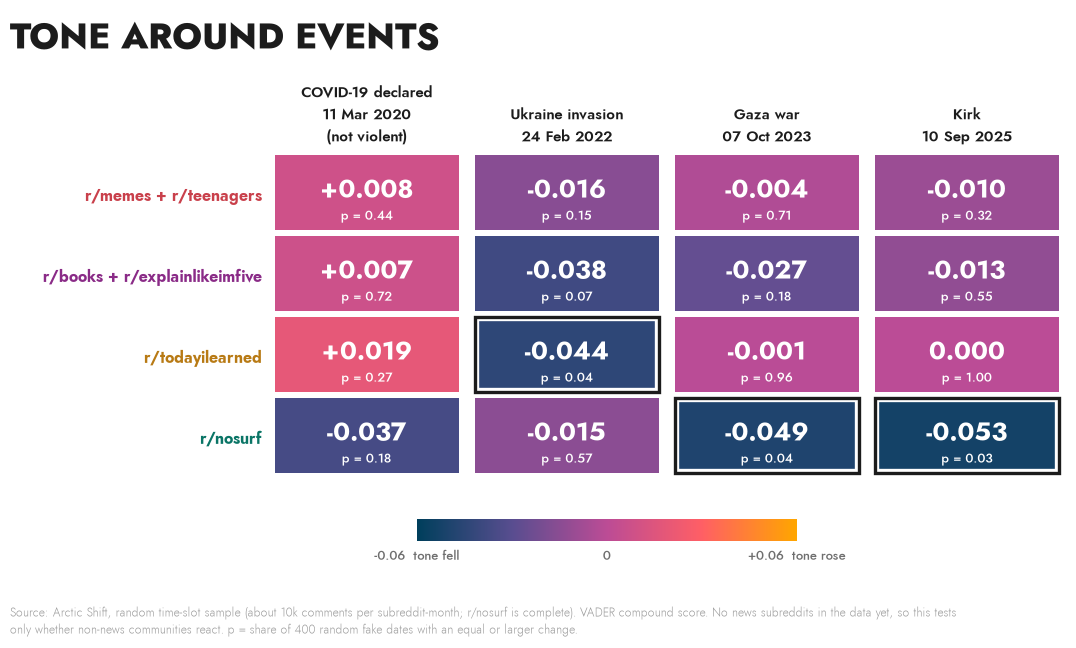

In [7]:
GROUP_LABEL = H4_GROUP_LABEL


def c21():
    gk = list(ev.GROUPS)
    cells = {(n, g): _eff(g, n, "sentiment") for n in EV_NAMES for g in gk}
    dips = sum(1 for n in EV_NAMES[1:] for g in gk if cells[(n, g)][0] < -0.0005)  # |change| < 0.0005 = none
    mx = max(abs(e) for e, _ in cells.values())
    n_sig = sum(1 for _, p in cells.values() if p < 0.05)
    finding = (f"After the three violent events tone dipped in {dips} of 12 community-event pairs, by no more than {mx:.2f} compound points; "
               f"{n_sig} of {len(cells)} tests (ringed) fall outside random dates, {0.05 * len(cells):.1f} expected by chance alone.")
    how = ("Each tile is one community and one event. The number is the change in mean tone (VADER, -1 to +1) in the 4 weeks after, compared with the "
           "8 weeks before. Dark blue = tone fell, amber = tone rose (the colours of the tone-change chart of the same authors), same scale in every tile. A thick ring means the change is beyond what random "
           "dates produce (p < 0.05); the p-value is in each tile.")
    LIM = 0.06
    with h4_style():
        fig = plt.figure(figsize=(11, 6.5))
        top = _top_in(fig, h4_title(fig, "Tone around events"))
        ax = fig.add_axes(_axbox(fig, 2.7, 1.7, 0.3, top + 0.75))
        for j, n in enumerate(EV_NAMES):
            for i, g in enumerate(gk):
                e, p = cells[(n, g)]
                rgb = H4_RAMP(0.5 + 0.5 * np.clip(e / LIM, -1, 1))  # 0 = ramp middle, like c26
                ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc=rgb, ec="none"))
                if p < 0.05:  # white halo, shows on any tile
                    ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc="none", ec="white", lw=6))
                    ax.add_patch(Rectangle((j + 0.04, i + 0.04), 0.92, 0.92, fc="none", ec=H4_INK, lw=2.4))
                dark = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2] < 0.55  # luminance flip for text
                ax.text(j + 0.5, i + 0.45, "0.000" if abs(e) < 0.0005 else f"{e:+.3f}", ha="center", va="center", fontsize=19, fontweight=700,
                        color="white" if dark else H4_INK)
                ax.text(j + 0.5, i + 0.78, f"p = {p:.2f}", ha="center", va="center", fontsize=9.5, color="white" if dark else H4_MUTED)
        ax.set_xlim(0, 4)
        ax.set_ylim(4, 0)
        ax.grid(False)
        ax.set_xticks(np.arange(4) + 0.5, [f"{EV_SHORT[n]}\n{pd.Timestamp(EVENTS[n]):%d %b %Y}" + ("\n(not violent)" if k == 0 else "")
                                           for k, n in enumerate(EV_NAMES)], fontsize=11, color=H4_INK, fontweight=600)
        ax.xaxis.tick_top()
        ax.set_yticks(np.arange(4) + 0.5, [GROUP_LABEL[g] for g in gk], fontsize=11.5, fontweight=700)
        for t, g in zip(ax.get_yticklabels(), gk):
            t.set_color(label_color(H4_GROUP[g]))
        cax = fig.add_axes(_axbox(fig, 4.2, 1.05, 3.0, fig.get_figheight() - 1.27))
        cax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=H4_RAMP, extent=[-LIM, LIM, 0, 1])
        cax.set_yticks([])
        cax.set_xticks([-LIM, 0, LIM], [f"-{LIM}  tone fell", "0", f"+{LIM}  tone rose"], fontsize=9.5, color=H4_MUTED)
        cax.grid(False)
        h4_foot(fig, f"{SAMPLE} VADER compound score. No news subreddits in the data yet, so this tests only whether non-news communities react. "
                     "p = share of 400 random fake dates with an equal or larger change.")
        return h4_done(fig, finding, how)


fig = c21()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C21:** drawn by the cell above; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q4. Did talk about doomscrolling rise after the events?
**Why we asked:** The doomscrolling half of H4: if crises push people to scroll, they might also talk about it.

**What we did:** r/nosurf only, where we hold every comment: `doomscroll*` and `doom surf*` mentions per 10,000 words, weekly, as a 4-week rolling rate from 2020, drawn smoothed once more with a 5-week moving average (the numbers below come from the unsmoothed 4-week rate), in the same look as the posts-per-day ridgeline (height and colour both show the rate, colour on a log scale); the events are dashed lines and the 4 test weeks after each are pale bands.

**Result:** The rate climbs steadily: 0.08 per 10,000 words in 2020, 0.29 in 2021, 0.66 in 2022, 1.14 in 2023, 1.88 in 2024, 3.24 in 2025 and 4.95 in 2026 (to September). The 4-week rate peaked at 6.3 in the week of 19 July 2026 and is 3.8 now. The four-week changes at the events are small blips on that rise: COVID 0.0 (p = 1.0), Ukraine +0.8 (p = 0.05), Gaza +0.5 (p = 0.16), Kirk -0.3 (p = 0.28), against a random-date spread of about 0.3.

**Interpretation:** The long-run climb is far larger than any event effect, so the events cannot explain it; only the Ukraine invasion is borderline, and it is one of four tests. Counting mentions measures talk about doomscrolling, not scrolling, and lurking is invisible; the word itself also spread over these years and the community grew.

**Next question:** Did brainrot words, the media-diet vocabulary, spike with the crises (Q5)?

**Doomscroll talk in r/nosurf climbed from 0.08 per 10,000 words in 2020 to 5.0 in 2026; the four events are small blips on that rise.**

*How to read: r/nosurf only: mentions of doomscroll* or doom surf* per 10,000 words, weekly, as a 4-week rolling rate, smoothed once more (5-week moving average). Dashed lines = the events; pale bands = the 4 weeks after each event that the test uses. Colour shows the same value as the height, on a log scale (bar on the right).*

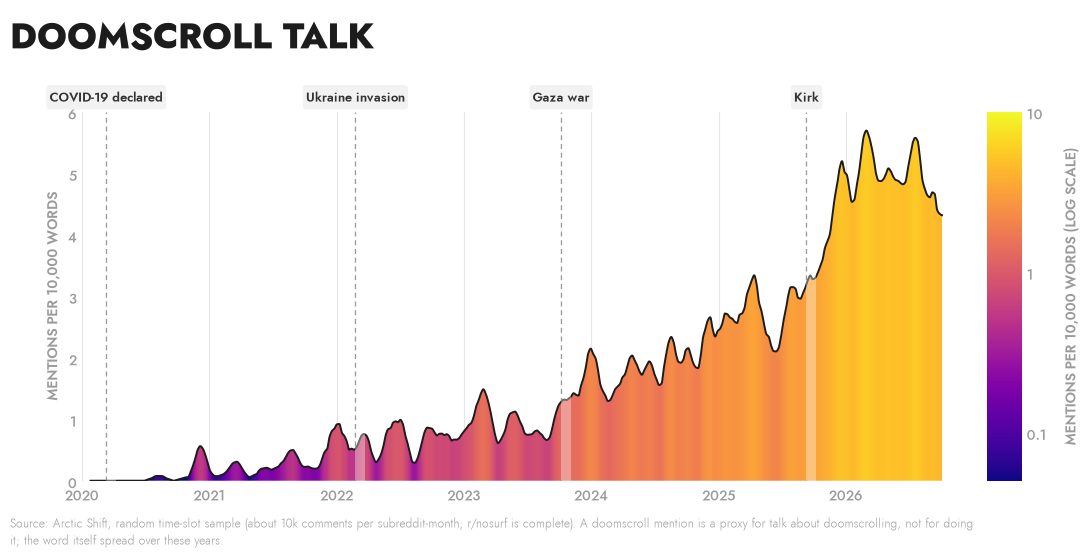

In [8]:
def _fmt(v):
    return f"{v:.2f}" if abs(v) < 1 else f"{v:.1f}"


def c22():
    d = ev.load_daily()
    x = d[d.subreddit == "nosurf"].set_index("day")[["hits_doom", "tokens"]]
    yr = x.groupby(x.index.year).sum()
    yr_rate = yr.hits_doom / yr.tokens * 1e4
    w = x.resample("W").sum()
    w = w[w.index >= "2020-01-01"]
    r = (w.hits_doom.rolling(4).sum() / w.tokens.rolling(4).sum() * 1e4).dropna()  # 4wk rate = number in text
    sm = r.rolling(5, center=True, min_periods=1).mean()  # display only: 5wk avg + pchip
    days = pd.date_range(sm.index[0], sm.index[-1], freq="D")
    yv = PchipInterpolator(mdates.date2num(sm.index), sm.to_numpy())(mdates.date2num(days))
    finding = (f"Doomscroll talk in r/nosurf climbed from {_fmt(yr_rate[2020])} per 10,000 words in 2020 to {_fmt(yr_rate[2026])} in 2026; "
               f"the four events are small blips on that rise.")
    how = ("r/nosurf only: mentions of doomscroll* or doom surf* per 10,000 words, weekly, as a 4-week rolling rate, smoothed once more (5-week moving average). Dashed lines = the events; "
           "pale bands = the 4 weeks after each event that the test uses. Colour shows the same value as the height, on a log scale (bar on the right).")
    with h4_style():
        fig = plt.figure(figsize=(11, 5.6))
        top = _top_in(fig, h4_title(fig, "Doomscroll talk"))
        ax = fig.add_axes(_axbox(fig, 0.85, 0.75, 1.45, top + 0.35))
        cax = fig.add_axes(_axbox(fig, 9.9, 0.75, 0.75, top + 0.35))
        ax.plot(days, yv, color=H4_INK, lw=1.4, zorder=4)
        norm, cmap = LogNorm(0.05, 10), plt.get_cmap("plasma")  # plasma log, like danylo's posts/day
        xn = mdates.date2num(days)
        grad = cmap(norm(np.clip(yv, 0.05, 10)))[None, :, :]
        poly = Polygon(np.column_stack([np.r_[xn, xn[::-1]], np.r_[yv, np.zeros(len(yv))]]), facecolor="none", edgecolor="none")
        ax.add_patch(poly)
        ymax = float(np.ceil(yv.max()))
        im = ax.imshow(grad, extent=[xn[0], xn[-1], 0, ymax], aspect="auto", origin="lower", zorder=3, interpolation="bilinear")
        im.set_clip_path(poly)
        for n in EV_NAMES:
            t = pd.Timestamp(EVENTS[n])
            ax.axvspan(t, t + pd.Timedelta(days=28), color="white", alpha=0.35, lw=0, zorder=5)
        h4_chips(ax, CHIPS, ypos=1.0)
        _year_axis(ax, 1)
        ax.set_ylim(0, ymax)
        ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2026-11-01"))
        ax.set_ylabel("MENTIONS PER 10,000 WORDS")
        cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
        cb.outline.set_visible(False)
        cb.set_ticks([0.1, 1, 10], labels=["0.1", "1", "10"])
        cb.ax.minorticks_off()
        cb.ax.tick_params(labelsize=10, length=0)
        cb.set_label("MENTIONS PER 10,000 WORDS (LOG SCALE)", labelpad=10)
        h4_foot(fig, f"{SAMPLE} A doomscroll mention is a proxy for talk about doomscrolling, not for doing it; the word itself spread over these years.")
        return h4_done(fig, finding, how)


fig = c22()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C22:** drawn by the cell above; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q5. Did brainrot words spike around the crises?
**Why we asked:** Brainrot vocabulary is the visible trace of the media diet in our data; if crises push people towards it, it should jump after them.

**What we did:** Stream graph of brainrot words per 10,000 words in r/memes + r/teenagers (monthly, 3-month mean, one band per word; the band thickness is the rate of that word). Axis from January 2022; COVID-19 (March 2020) is before the slang existed. Monthly resolution only.

**Result:** In all six subreddits together, rizz is 83% of brainrot-word hits in 2022, skibidi (23%) and gyatt (9%) join in 2023, and 'brain rot' / 'brainrot' take 41% in 2024 and 72% in 2025. Around the Gaza war and Kirk's killing only 1 of 12 term-event checks beats random dates: 'gyatt' after Gaza (0.04 to 0.23 per 10,000 words, p = 0.02, 5 hits in the four weeks). 'skibidi' after Gaza (0.13 to 0.54, p = 0.20) and 'brain rot' after Kirk (0.38 to 0.79, 26 hits, p = 0.21) rose but not beyond random dates.

**Interpretation:** No brainrot word spikes with the crises beyond what random dates produce. Monthly resolution hides reactions shorter than a month (the same checks on weekly data give the same picture). Not charted: exact comments per day of the two subreddits, three months after versus before the event month, fell 19% after the Ukraine invasion (131,000 to 106,000) and 21% after the Gaza war (47,000 to 37,000) and 2% after Kirk's killing (34,000 to 33,000), following the long decline of both communities (`src/checks.py`).

**Next question:** Do posting sessions in r/nosurf get longer (Q6)?

**Brainrot words in r/memes and r/teenagers did not spike with the crises: only 1 of 12 term-event checks (Gaza war, Kirk's killing) beats random dates ('gyatt' after the Gaza war, +0.19 per 10,000 words, p = 0.02).**

*How to read: Brainrot words per 10,000 words in r/memes + r/teenagers; the thickness of each band is the rate of that word (3-month average). Dashed lines = events; monthly resolution only, so effects shorter than about a month cannot show. COVID-19 (March 2020) is before the slang existed and outside the axis.*

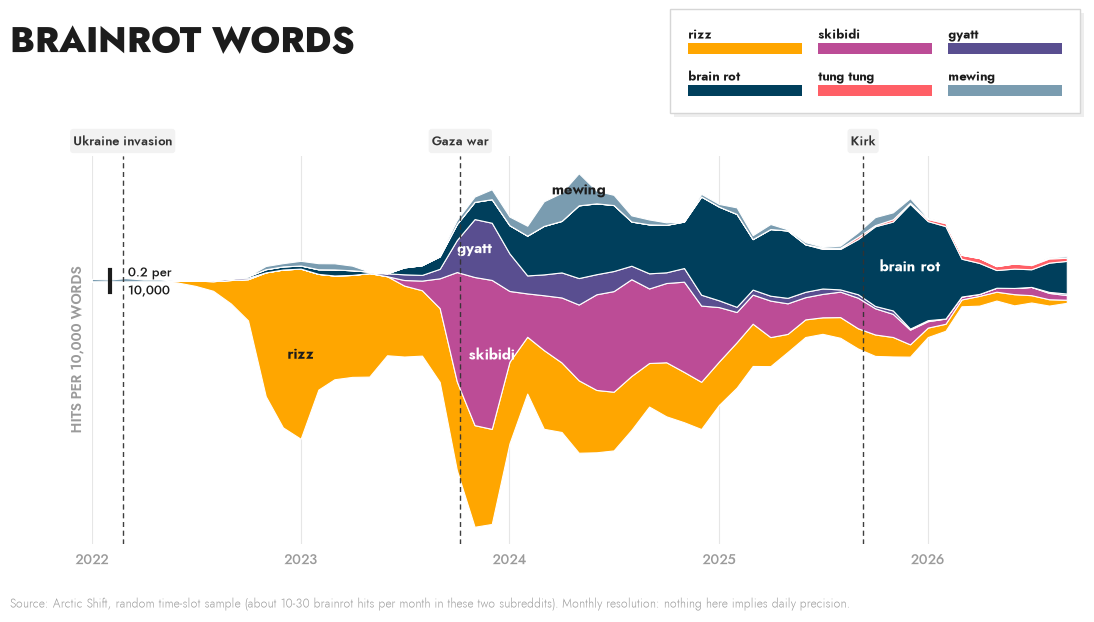

In [9]:
SHORT = ["memes", "teenagers"]


TERM_ORDER = ["rizz", "skibidi", "gyatt", "brain rot", "tung tung", "mewing"]


def _term_findings(subs):
    # gaza + kirk only, slang absent before
    t = ev.term_event_effects(subs)
    t = t[t.event.isin([EV_NAMES[2], EV_NAMES[3]])]
    sig = t[t.placebo_p < 0.05]
    if sig.empty:
        return t, sig, f"none of {len(t)} term-event checks (Gaza war, Kirk's killing) beats random dates"
    r = sig.iloc[0]
    return t, sig, (f"only {len(sig)} of {len(t)} term-event checks (Gaza war, Kirk's killing) beats random dates "
                    f"('{r.term}' after the {EV_SHORT[r.event]}, {r.change:+.2f} per 10,000 words, p = {r.placebo_p:.2f})")


def c23():
    tt = pd.read_parquet(AGG / "lexicon_terms_by_month.parquet")
    tt = tt[(tt.type == "comment") & tt.tier.isin(["core", "extended"]) & tt.subreddit.isin(SHORT)].copy()
    tt["g"] = tt["term"].map(ev.term_group)
    ov = pd.read_parquet(AGG / "overview_counts.parquet")
    tok = ov[(ov.type == "comment") & ov.subreddit.isin(SHORT)].groupby("month")["tokens"].sum()
    full = pd.date_range("2022-01-01", "2026-09-01", freq="MS")
    p = tt.groupby(["month", "g"])["n"].sum().unstack().reindex(columns=TERM_ORDER).reindex(full).fillna(0)
    rate = (p.div(tok.reindex(full), axis=0) * 1e4).rolling(3, min_periods=1, center=True).mean()
    _, _, sentence = _term_findings(SHORT)
    finding = f"Brainrot words in r/memes and r/teenagers did not spike with the crises: {sentence}."
    how = ("Brainrot words per 10,000 words in r/memes + r/teenagers; the thickness of each band is the rate of that word (3-month average). "
           "Dashed lines = events; monthly resolution only, so effects shorter than about a month cannot show. "
           "COVID-19 (March 2020) is before the slang existed and outside the axis.")
    with h4_style():
        fig = plt.figure(figsize=(11, 6.2))
        top = _top_in(fig, h4_title(fig, "Brainrot words"))
        ax = fig.add_axes(_axbox(fig, 0.95, 0.75, 0.3, top + 0.75))
        y = rate.T.to_numpy()
        ax.stackplot(rate.index, y, colors=[H4_TERMS[t] for t in TERM_ORDER], baseline="wiggle", edgecolor="white", linewidth=0.8)
        m = len(TERM_ORDER)
        base = -(y * (m - 0.5 - np.arange(m)[:, None])).sum(axis=0) / m
        lower = base + np.vstack([np.zeros(y.shape[1]), np.cumsum(y, axis=0)[:-1]])
        thick = y.sum(axis=0).max()
        for i, t in enumerate(TERM_ORDER):
            j = int(np.argmax(y[i]))
            if y[i, j] >= 0.06 * thick:
                ax.text(rate.index[j], lower[i, j] + y[i, j] / 2, t, ha="center", va="center", fontsize=10.5, fontweight=700,
                        color="white" if t in ("brain rot", "gyatt", "tung tung", "skibidi") else H4_INK)
        ax.set_yticks([])
        ax.set_ylabel("HITS PER 10,000 WORDS")
        ax.plot([pd.Timestamp("2022-02-01")] * 2, [-0.1, 0.1], color=H4_INK, lw=3)
        ax.text(pd.Timestamp("2022-03-05"), 0, "0.2 per\n10,000", va="center", fontsize=9, color=H4_INK)
        for date, _lab in CHIPS[1:]:
            ax.axvline(pd.Timestamp(date), color="#333", lw=0.9, ls=(0, (4, 3)), alpha=0.75, zorder=5)
        h4_chips(ax, CHIPS[1:], ypos=1.0)
        ax.set_xlim(full[0], full[-1])
        ax.grid(axis="y", visible=False)
        ax.xaxis.set_major_locator(mdates.YearLocator(1, month=1, day=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        h4_legend(fig, [(t, H4_TERMS[t], None) for t in TERM_ORDER], ncol=3, col_w=1.3, y_top=1 - 0.1 / 6.2)
        h4_foot(fig, "Source: Arctic Shift, random time-slot sample (about 10-30 brainrot hits per month in these two subreddits). Monthly resolution: "
                     "nothing here implies daily precision.")
        return h4_done(fig, finding, how)


fig = c23()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C23:** drawn by the cell above; reads `lexicon_terms_by_month`, `overview_counts`; built by `python run_pipeline.py aggregates, text`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q6. Did posting sessions in r/nosurf get longer?
**Why we asked:** Longer unbroken stretches of activity are the closest thing to a scrolling session that posting data can show.

**What we did:** Gap-based sessions (messages by one author with gaps of at most 30 minutes) from comments and submissions, r/nosurf only: sessions with 2 or more messages split into five length buckets (1 minute, 2-4, 5-9, 10-29, 30+), bars = share of those sessions in each bucket, one colour per bucket), 8 weeks before (light, outlined bars) versus 4 weeks after (solid bars), one panel per event. As a yardstick we repeated the largest bucket shift at 100 random fake dates.

**Result:** The share of sessions with two or more messages is 11.5% vs 11.4% (COVID), 13.9% vs 11.9% (Ukraine), 12.5% vs 13.3% (Gaza) and 17.0% vs 16.0% (Kirk); their median length is 6 vs 6 minutes, 6 vs 9, 6 vs 7 and 6 vs 6. Around COVID, Gaza and Kirk no length bucket moves by more than about 3 percentage points. After the Ukraine invasion the 10-29 minute bucket grows from 30% to 39% of the sessions with two or more messages (+9.2 points) while 1-minute and 2-4-minute sessions shrink (21% to 17% each); that shift is beyond what random dates produce (p = 0.02).

**Interpretation:** Three of four events leave sessions unchanged and one, the Ukraine invasion, moves them towards 10-29 minutes. With four events tested, one p-value of 0.02 or lower happens about 8% of the time by chance, so it is a lead worth a look, not a conclusion. Sessions only see active posting; reading without posting is invisible.

**Next question:** Do the same people change (Q7)?

**Posting sessions in r/nosurf kept their usual length around three events (no length bucket moves more than 3.3 points; typical session 6-9 minutes); after the Ukraine invasion the 10-29 min bucket grew from 30% to 39% of sessions, beyond what random dates produce (p = 0.02).**

*How to read: Share of posting sessions (2 or more messages) by how long they lasted. Colour = length bucket (dark blue = 1 minute to amber = 30+ minutes); light outlined bars = the 8 weeks before the event, solid bars = the 4 weeks after it; one panel per event.*

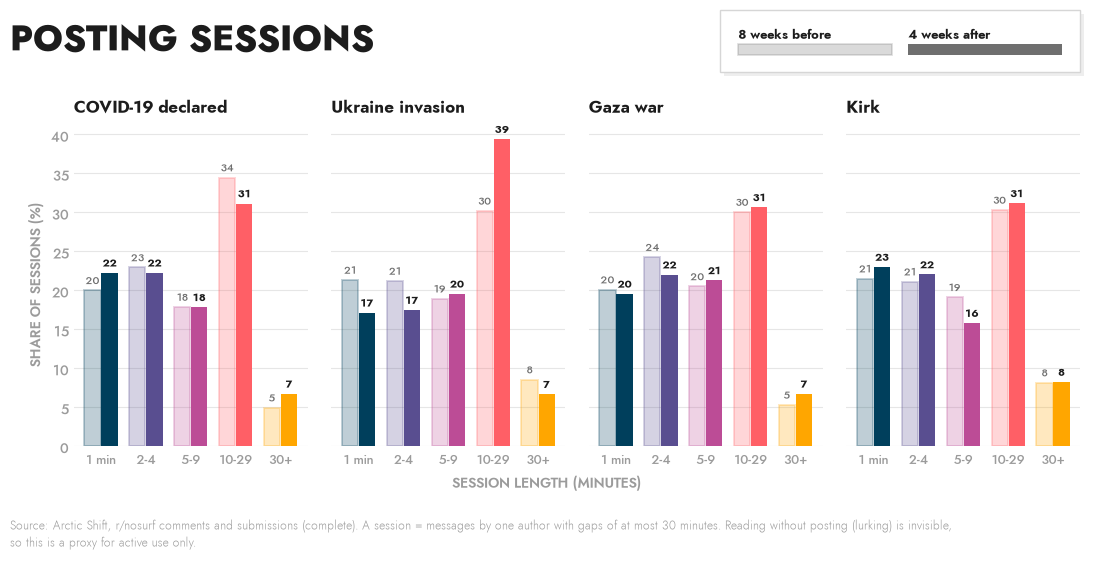

In [10]:
def c24():
    st = ev.session_stats()
    W, med, big, top_n, others, p_big = st["W"], st["med"], st["big"], st["top"], st["others"], st["p"]
    allm = [v for m in med.values() for v in m]
    verb = "grew" if big[top_n][1] > big[top_n][0] else "shrank"
    finding = (f"Posting sessions in r/nosurf kept their usual length around three events (no length bucket moves more than {others:.1f} points; typical session "
               f"{min(allm):.0f}-{max(allm):.0f} minutes); after the {EV_SHORT[top_n]} the {big[top_n][2]} min bucket {verb} from {big[top_n][0]:.0f}% to "
               f"{big[top_n][1]:.0f}% of sessions, {'beyond' if p_big < 0.05 else 'within'} what random dates produce (p = {p_big:.2f}).")
    how = ("Share of posting sessions (2 or more messages) by how long they lasted. Colour = length bucket (dark blue = 1 minute to amber = 30+ minutes); "
           "light outlined bars = the 8 weeks before the event, solid bars = the 4 weeks after it; one panel per event.")
    with h4_style():
        fig, axes = plt.subplots(1, 4, figsize=(11, 5.6), sharey=True)
        top = _top_in(fig, h4_title(fig, "Posting sessions"))
        for ax, n in zip(axes, EV_NAMES):
            a, b = W[n]
            for k, (lo, hi, lab) in enumerate(ev.BUCKETS):
                sa, sb = ((a >= lo) & (a <= hi)).mean() * 100, ((b >= lo) & (b <= hi)).mean() * 100
                col = H4_RAMP_COLORS[k]
                ax.bar(k - 0.19, sa, width=0.36, facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.4)
                ax.bar(k + 0.19, sb, width=0.36, color=col)
                ax.text(k - 0.19, sa + 0.8, f"{sa:.0f}", ha="center", fontsize=8, color=H4_MUTED)
                ax.text(k + 0.19, sb + 0.8, f"{sb:.0f}", ha="center", fontsize=8, fontweight=700, color=H4_INK)
            ax.set_title(EV_SHORT[n], fontsize=12.5, fontweight=700, pad=8)
            ax.set_xticks(range(5), [b[2] for b in ev.BUCKETS], fontsize=9)
            ax.grid(axis="x", visible=False)
        axes[0].set_ylabel("SHARE OF SESSIONS (%)")
        fig.text(0.5, 0.125, "SESSION LENGTH (MINUTES)", ha="center", fontsize=10, fontweight=600, color=H4_FAINT)
        fig.subplots_adjust(top=1 - (top + 0.45) / 5.6, bottom=0.2, left=0.07, right=0.985, wspace=0.1)
        h4_legend(fig, [("8 weeks before", H4_MUTED, "outline"), ("4 weeks after", H4_MUTED, None)], ncol=2, col_w=1.7)
        h4_foot(fig, "Source: Arctic Shift, r/nosurf comments and submissions (complete). A session = messages by one author with gaps of at most 30 minutes. "
                     "Reading without posting (lurking) is invisible, so this is a proxy for active use only.")
        return h4_done(fig, finding, how)


fig = c24()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C24:** drawn by the cell above; reads `processed Parquet (data/processed)`; built by `python run_pipeline.py clean`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q7. Do the same r/nosurf authors write differently after an event?
**Why we asked:** A change in average tone could come from different people posting; following the same authors removes that.

**What we did:** Authors with comments in both windows (8 weeks before, 4 weeks after): each dot is one author's change in mean VADER score, the cloud is the same data as a distribution (colour = size of the change), the big dot and bar are the mean with a 95% bootstrap interval, and the gray band is the 95% range of the same statistic at 120 random fake dates.

**Result:** The same authors wrote less positively after all four events: -0.037 (COVID, 322 authors), -0.042 (Ukraine, 401), -0.058 (Gaza, 385), -0.070 (Kirk, 613). The intervals of Gaza and Kirk exclude zero; only the Kirk change lies outside the random-date band (-0.063 to +0.058).

**Interpretation:** A consistent small negative shift among people who keep posting, in the one community where we see everyone. But random dates also produce shifts of this size, and the topic of the week (people discussing the news in their own words) changes the vocabulary VADER reads, so this is tone of the text, not mood of the people.

**Next question:** What would settle H4? News subreddits as a contrast group and a hand-checked sentiment measure.

**The same r/nosurf authors wrote less positively after all four events (-0.07 to -0.04); 1 of 4 shifts falls outside random dates (Kirk).**

*How to read: Each dot is one author who posted in both windows: how much their average tone changed (4 weeks after vs 8 weeks before). The cloud above the dots is the same data as a distribution; colour shows the size of the change. Big dot and bar = group mean with 95% interval. Gray band = what random dates produce.*

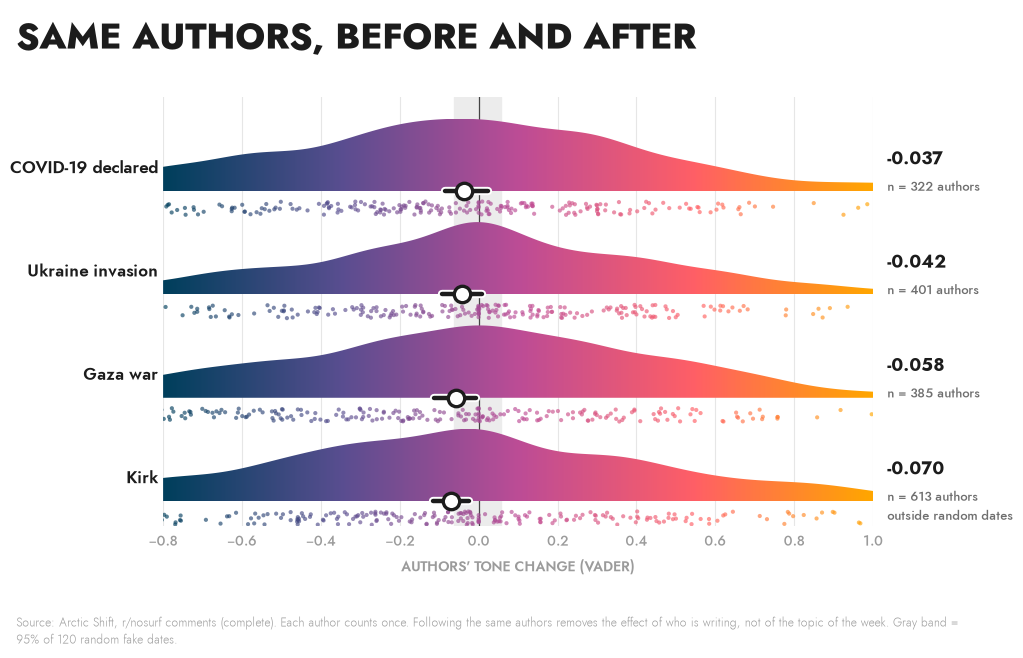

In [11]:
def c26():
    from scipy.stats import gaussian_kde
    D, CI, lo_f, hi_f = ev.authors_stats()
    means = [D[n].mean() for n in EV_NAMES]
    outside = [n for n in EV_NAMES if D[n].mean() < lo_f or D[n].mean() > hi_f]
    direction = "less positively after all four events" if max(means) < 0 else "differently after the events"
    finding = (f"The same r/nosurf authors wrote {direction} ({min(means):+.2f} to {max(means):+.2f}); "
               f"{len(outside)} of 4 shifts {'falls' if len(outside) == 1 else 'fall'} outside random dates" + (f" ({', '.join(EV_SHORT[n] for n in outside)})." if outside else "."))
    how = ("Each dot is one author who posted in both windows: how much their average tone changed (4 weeks after vs 8 weeks before). The cloud above the dots "
           "is the same data as a distribution; colour shows the size of the change. Big dot and bar = group mean with 95% interval. Gray band = what random dates produce.")
    norm = Normalize(-0.8, 1.0)
    with h4_style():
        fig = plt.figure(figsize=(11, 6.6))
        top = _top_in(fig, h4_title(fig, "Same authors, before and after"))
        ax = fig.add_axes(_axbox(fig, 1.6, 1.3, 2.3, top + 0.2))
        ax.axvspan(lo_f, hi_f, color="#ececec", zorder=0)
        ax.axvline(0, color="#444", lw=0.9, zorder=1)
        xs = np.linspace(-0.8, 1.0, 400)
        grad = H4_RAMP(norm(xs))[None, :, :]
        r2 = np.random.default_rng(1)
        for i, n in enumerate(EV_NAMES[::-1]):
            off, d = float(i), D[n]
            k = gaussian_kde(d, bw_method=0.18)(xs)
            k = k / k.max() * 0.7
            poly = Polygon(np.column_stack([np.r_[xs, xs[::-1]], np.r_[off + 0.14 + k, np.full_like(xs, off + 0.14)]]), facecolor="none", edgecolor="none",
                           transform=ax.transData)
            ax.add_patch(poly)
            im = ax.imshow(grad, extent=[xs[0], xs[-1], off + 0.14, off + 0.14 + 0.7], aspect="auto", origin="lower", zorder=3, interpolation="bilinear")
            im.set_clip_path(poly)
            sel = r2.choice(len(d), min(len(d), 240), replace=False)
            ax.scatter(d[sel], off + 0.04 - r2.uniform(0, 0.13, len(sel)), s=9, c=d[sel], cmap=H4_RAMP, norm=norm, alpha=0.65, lw=0, zorder=4)
            ax.plot(CI[n], [off + 0.14] * 2, color="white", lw=6, solid_capstyle="round", zorder=5)
            ax.plot(CI[n], [off + 0.14] * 2, color=H4_INK, lw=3.2, solid_capstyle="round", zorder=6)
            ax.scatter([d.mean()], [off + 0.14], s=140, color="white", ec=H4_INK, lw=2.4, zorder=7)
            ax.text(1.02, off + 0.46, f"{d.mean():+.3f}", transform=ax.get_yaxis_transform(), fontsize=13, fontweight=700, ha="left", va="center")
            note = f"n = {len(d)} authors" + ("\noutside random dates" if n in outside else "")
            ax.text(1.02, off + 0.28, note, transform=ax.get_yaxis_transform(), fontsize=9.5, ha="left", va="top", color=H4_MUTED)
        ax.set_yticks([i + 0.4 for i in range(4)], [EV_SHORT[n] for n in EV_NAMES[::-1]], fontsize=12, fontweight=600, color=H4_INK)
        ax.grid(axis="y", visible=False)
        ax.set_xlim(-0.8, 1.0)
        ax.set_ylim(-0.1, 4.05)
        ax.set_xlabel("AUTHORS' TONE CHANGE (VADER)")
        h4_foot(fig, "Source: Arctic Shift, r/nosurf comments (complete). Each author counts once. Following the same authors removes the effect of who is writing, "
                     "not of the topic of the week. Gray band = 95% of 120 random fake dates.")
        return h4_done(fig, finding, how)


fig = c26()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

**Data and pipeline for C26:** drawn by the cell above; reads `per-comment features (data/processed/derived)`; built by `python run_pipeline.py features`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

## What H4 shows
- **Events reach the communities.** Event words rose in 13 of 16 community-event pairs; r/todayilearned is the exception (Q2).
- **Tone: small, consistent direction, weak evidence.** Tone was lower after the three violent events in 11 of 12 pairs, by at most 0.05; three of 16 tests are outside the placebo range, about what we would expect by chance given many correlated tests (Q3). The same r/nosurf authors wrote 0.04-0.07 less positively afterwards, only Kirk beyond random dates (Q7).
- **Doomscroll talk climbs steadily, the events do not explain it.** In r/nosurf the rate went from 0.08 per 10,000 words in 2020 to 4.95 in 2026; the event effects are small blips (Q4).
- **Brainrot words do not spike with the crises.** One of 12 term-event checks (gyatt after the Gaza war) is beyond random dates; the vocabulary behaves like a slow trend (Q5).
- **Posting sessions** are unchanged at three events; after the Ukraine invasion r/nosurf sessions shifted towards 10-29 minutes (30% to 39% of sessions with 2+ messages, p = 0.02), one of four events (Q6).
- **Also checked, not charted:** the daily rhythm of r/nosurf (the largest hour-by-weekday shift at any event is 0.37-0.77 percentage points; 95% of random dates stay under 0.82) and monthly changes in the World Uncertainty Index against tone and crisis words (largest correlation 0.19 against a noise band of 0.15): nothing in either. Change-point detection on each community's monthly tone finds 17 shifts, only 1 within three months of an event (about 3 expected by chance), and the brainrot-word checks on weekly data show the same picture as Q5.
- **Not yet tested:** the news-subreddit contrast, which is the cleanest way to separate "the crisis" from general drift; hand-validated sentiment.